## Case Study: Predicting AttorneyRepresentation in Insurance Claims

In [11]:
# Importing Libraries

import pandas as pd
from sklearn.linear_model import LogisticRegression

In [12]:
df_cl = pd.read_csv("claimants.csv")
df_cl.head()

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038


## Data Shape and Unique Values

In [13]:
df_cl.shape

(1340, 7)

In [14]:
len(df_cl['CASENUM'].unique())

1283

## Dropping Irrelevant Column

In [15]:
# dropping the case number column as it is not required
df_cl.drop(["CASENUM"], inplace = True, axis =1)

In [16]:
df_cl.shape

(1340, 6)

In [17]:
df_cl.head()

,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,0,0.0,1.0,0.0,50.0,34.940
1,1,1.0,0.0,0.0,18.0,0.891
2,1,0.0,1.0,0.0,5.0,0.330
3,0,0.0,1.0,1.0,31.0,0.037
4,1,0.0,1.0,0.0,30.0,0.038


## Handling the missing values

In [18]:
df_cl.isnull().sum()

ATTORNEY      0
CLMSEX       12
CLMINSUR     41
SEATBELT     48
CLMAGE      189
LOSS          0
dtype: int64

In [19]:
## Removing the NA values in the data set
df_cl = df_cl.dropna()
df_cl.shape

(1096, 6)

In [20]:
df_cl.isnull().sum()

ATTORNEY    0
CLMSEX      0
CLMINSUR    0
SEATBELT    0
CLMAGE      0
LOSS        0
dtype: int64

In [21]:
X = df_cl.iloc[:,1:] #Features (all columns expect ATTORNEY)
Y = df_cl.iloc[:,0] # Target Attorney

## Split into train and test data

In [22]:
from sklearn.model_selection import train_test_split

In [23]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size = 0.2, random_state = 42)

In [24]:
X_train.shape, Y_train.shape

((876, 5), (876,))

In [25]:
X_test.shape, Y_test.shape

((220, 5), (220,))

In [26]:
X.head()

,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,0.0,1.0,0.0,50.0,34.940
1,1.0,0.0,0.0,18.0,0.891
2,0.0,1.0,0.0,5.0,0.330
3,0.0,1.0,1.0,31.0,0.037
4,0.0,1.0,0.0,30.0,0.038


In [27]:
Y.head()

0    0
1    1
2    1
3    0
4    1
Name: ATTORNEY, dtype: int64

## Training the Logistic Regression Model

In [28]:
from sklearn.linear_model import LogisticRegression

classifier = LogisticRegression()
classifier.fit(X_train, Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


## Evaluate on Test Set

In [29]:
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score

In [30]:
y_pred_test = classifier.predict(X_test)

In [31]:
# Accuracy

accuracy = accuracy_score(Y_test, y_pred_test)
print("Accuracy:", accuracy)

Accuracy: 0.6772727272727272


In [32]:
classifier.predict_proba(X)

array([[9.99999654e-01, 3.45984944e-07],
       [4.85974592e-01, 5.14025408e-01],
       [4.00591883e-01, 5.99408117e-01],
       ...,
       [2.59655148e-01, 7.40344852e-01],
       [7.34762987e-01, 2.65237013e-01],
       [3.23400218e-01, 6.76599782e-01]], shape=(1096, 2))

In [35]:
# Confusion Matrix

print("Confusion_Matrix:\n", confusion_matrix(Y_test, y_pred_test))

Confusion_Matrix:
 [[77 34]
 [37 72]]


In [36]:
# AUC_ROC

auc = roc_auc_score(Y_test, classifier.predict_proba(X_test)[:,1])
print("Test AUC:",auc)

Test AUC: 0.7212579552029093


In [39]:
y_pred_df = pd.DataFrame({ "actual":Y,
                           "predicted_proba": classifier.predict(X)})

In [40]:
y_pred_df.head()

,actual,predicted_proba
0,0,0
1,1,1
2,1,1
3,0,1
4,1,1


## ROC_AUC Curve

AUC Score: 0.721


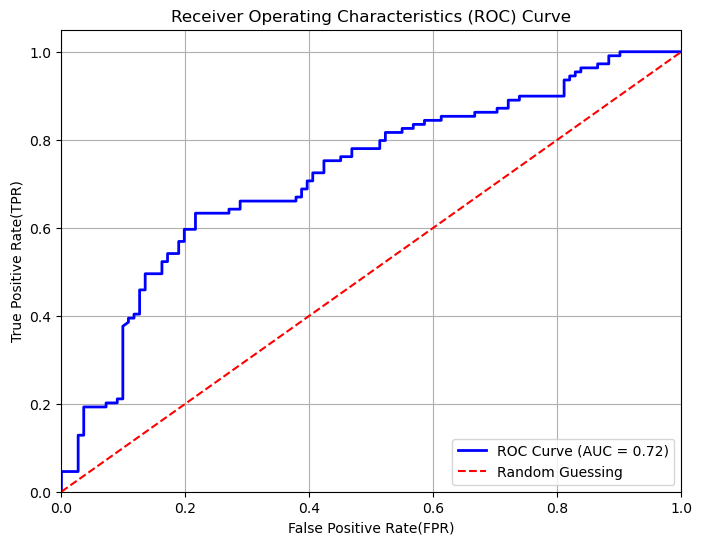

In [44]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

#Get predicted probabilities for the positive class( ATTORNEY =1)
y_pred_proba = classifier.predict_proba(X_test)[:,1] #Probabilities for class 1

# Calculate ROC curve metrics
fpr, tpr, thresholds = roc_curve(Y_test,y_pred_proba)

# Calculate AUC score
auc_score = roc_auc_score(Y_test,y_pred_proba)
print(f"AUC Score: {auc_score:.3f}")

#Plot ROC Curve
plt.figure(figsize = (8,6))
plt.plot(fpr,tpr, color = "blue", lw =2,label = f"ROC Curve (AUC = {auc_score:.2f})")
plt.plot([0,1],[0,1], color = 'red', linestyle="--", label = "Random Guessing")

#Customize plot

plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel("False Positive Rate(FPR)")
plt.ylabel("True Positive Rate(TPR)")
plt.title("Receiver Operating Characteristics (ROC) Curve")
plt.legend(loc = "lower right")
plt.grid(True)
plt.show()

In [45]:
## Compare train vs. test Performance

In [46]:
y_pred_train = classifier.predict(X_train)
print("Train Accuracy :", accuracy_score(Y_train, y_pred_train))

Train Accuracy : 0.7146118721461188


In [48]:
from sklearn.metrics import accuracy_score

# Get predection for both train and test sets
y_pred_train = classifier.predict(X_train)
y_pred_test = classifier.predict(X_test)

#Calculate Acuracy
train_accuracy = accuracy_score(Y_train, y_pred_train)
test_accuracy = accuracy_score(Y_test, y_pred_test)
print("train_accuracy",train_accuracy)
print("test_accuracy", test_accuracy)
# Determin generalization status

if abs(train_accuracy - test_accuracy) < 0.5:
    print("Good Generalization")
elif train_accuracy > test_accuracy + 0.1:
    print("Overfitting detected")
    print("Add regularization")
    print("Reduce features")
    print("Increase training data")
else:
    print("Check model or data(unexpected gap)")

train_accuracy 0.7146118721461188
test_accuracy 0.6772727272727272
Good Generalization
